# Generation Visualizer

Visualises *where* the RL agent places synthetic points in PCA space and how that changes across training.

**Sections**
1. Config & data loading
2. Static spatial overview (PC1 × PC2, alpha confidence background)
3. Generation drift across training snapshots
4. Training dynamics linked to spatial behaviour
5. Confidence profile of generated points over training
6. Reward alignment diagnostic (anchor vs hard reward)

In [1]:
# ============================================================
# CELL 1 – CONFIG  (edit here)
# ============================================================
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/epigou/cs_9170_project")
sys.path.insert(0, str(PROJECT_ROOT))

# ── Pick a run directory and seed ────────────────────────────
RUNS_ROOT = PROJECT_ROOT / "training_runs"

# List available experiment dirs that contain seed subdirs
def list_runs():
    for d in sorted(RUNS_ROOT.iterdir()):
        if d.is_dir() and any(s.is_dir() and s.name.startswith("seed_") for s in d.iterdir()):
            print(d.name)

list_runs()

BASELINE_gaussian_ot_repair_baseline_otrep_census_a8b46764__G202603111900
BASELINE_gaussian_ot_repair_baseline_otrep_credit_6882b6a2__G202603111900
BASELINE_group_dro_baseline_gdro_census_663e8736__G202603121735
BASELINE_group_dro_baseline_gdro_census_738fc989__G202603111900
BASELINE_group_dro_baseline_gdro_credit_0f79e8fe__G202603121736
BASELINE_group_dro_baseline_gdro_credit_153d34a0__G202603111900
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_97f273d4
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603121842_acafe162
SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603131643_0520d348
SPECv3_census_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_2f9e695b
SPECv3_census_ablation_global_hard_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_64d2ac98
SPECv3_censu

In [2]:
# ── Paste the run name and seed you want to inspect ──────────
RUN_NAME = "SPECv7_census_hard_anchors_smoke_EP200_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603141341_115056d9"
SEED     = 42
ANCHOR_TOP_K = 150   # must match spec (census=150, credit=100)

# Derived paths
RUN_DIR  = RUNS_ROOT / RUN_NAME
SEED_DIR = RUN_DIR / f"seed_{SEED}"
assert SEED_DIR.exists(), f"Not found: {SEED_DIR}"

In [3]:
# ============================================================
# CELL 2 – LOAD DATA, ALPHA MODEL, ANCHORS
# ============================================================
import json
import numpy as np
import pandas as pd
import torch

from dataset import Dataset
from agents.ffnn_agent2 import FFNNAgent
import reward_helpers as rh

# ── Meta ─────────────────────────────────────────────────────
with open(SEED_DIR / "meta.json") as f:
    meta = json.load(f)
with open(SEED_DIR / "ffnn_meta.json") as f:
    ffnn_meta = json.load(f)

DATASET_NAME   = meta["dataset_name"]
PCA_COMPONENTS = ffnn_meta["n_pca_components"]
MINORITY_ID    = meta.get("minority_id", 1)
MAJORITY_ID    = meta.get("majority_id", 0)
REAL_DATA_SIZE = meta.get("REAL_DATA_SIZE", 3000)
BIAS_PCT       = meta.get("BIAS_PCT", None)

print(f"Dataset: {DATASET_NAME}  |  PCA dims: {PCA_COMPONENTS}  |  Seed: {SEED}")

# ── Load real data (same seed/split as training) ─────────────
ds = Dataset(
    dataset_name=DATASET_NAME,
    multiclass=meta.get("multiclass", False),
    minority_id=MINORITY_ID,
    majority_id=MAJORITY_ID,
    third_id=None,
    pca_components=PCA_COMPONENTS,
    seed=SEED,
    device="cpu",
    use_pca=True,
)
X_tr, X_val, X_te, y_tr, y_val, y_te = ds.get_data_splits(
    train_size=REAL_DATA_SIZE,
    bias_pct=BIAS_PCT,
    pca_components=PCA_COMPONENTS,
    drop_protected=False,
    protected_cols=ds.protected_attributes,
    bias_val=True,
)
a_train = ds.a_train.numpy()          # protected attribute (0/1)

X_tr_np = X_tr.numpy() if isinstance(X_tr, torch.Tensor) else X_tr
y_tr_np = y_tr.numpy() if isinstance(y_tr, torch.Tensor) else y_tr

print(f"Train: {X_tr_np.shape}  minority={y_tr_np.sum()}  majority={(y_tr_np==0).sum()}")

# ── Load alpha model ──────────────────────────────────────────
alpha = FFNNAgent(
    input_size=PCA_COMPONENTS,
    hidden_sizes=ffnn_meta["hidden_sizes"],
    output_size=ffnn_meta["output_size"],
    type="classification",
    classes=ffnn_meta["classes"],
    device="cpu",
    seed=SEED,
)
alpha.model.load_state_dict(torch.load(SEED_DIR / "alpha_state_dict.pt", map_location="cpu"))
alpha.model.eval()
print("Alpha model loaded.")

# ── Reconstruct hard-positive anchors (same logic as training) ─
disadv_mask  = (a_train == MINORITY_ID)   # disadvantaged group
pos_mask     = (y_tr_np == 1)             # positive label
anchor_mask  = disadv_mask & pos_mask
anchor_pool  = torch.tensor(X_tr_np[anchor_mask], dtype=torch.float32)

with torch.no_grad():
    p_alpha_pool = rh.p1_from_agent(alpha, anchor_pool)

n_sel = min(ANCHOR_TOP_K, anchor_pool.shape[0])
_, hard_idx = p_alpha_pool.topk(n_sel, largest=False)   # lowest p = hardest
anchors_np = anchor_pool[hard_idx].numpy()
p_anchors  = p_alpha_pool[hard_idx].numpy()

print(f"Anchors: {n_sel}/{anchor_pool.shape[0]}  p_alpha range [{p_anchors.min():.3f}, {p_anchors.max():.3f}]")

Dataset: census_income  |  PCA dims: 10  |  Seed: 42
[TRAIN] size=3000, minority=722 (24.07%)
[VAL] size=6512, minority=1568 (24.08%)
[TEST] size=6513, minority=1569 (24.09%)
Train: (3000, 10)  minority=722  majority=2278
FFNN Using device: cpu
Alpha model loaded.
Anchors: 150/606  p_alpha range [0.001, 0.367]


Computing confidence grid…


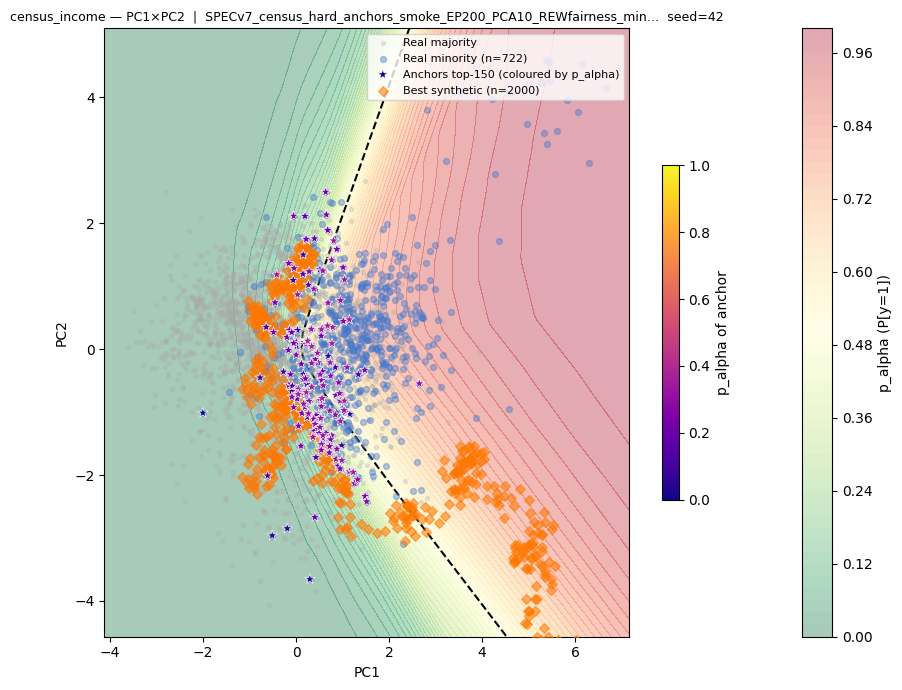

Dashed line = decision boundary (p_alpha=0.5). Anchors should cluster near it.


In [4]:
# ============================================================
# CELL 3 – STATIC SPATIAL OVERVIEW  (PC1 × PC2)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load best synthetic
syn_df = pd.read_csv(SEED_DIR / "best_synthetic_phase1_class1.csv")
pca_cols = [f"pca_{i}" for i in range(PCA_COMPONENTS)]
syn_np = syn_df[pca_cols].values

# ── Alpha confidence heatmap on PC1×PC2 grid ─────────────────
def alpha_confidence_grid(alpha_model, X_ref, pc_x=0, pc_y=1, margin=0.5, n=120):
    """Evaluate p_alpha on a 2D grid over pc_x × pc_y; other dims = mean of X_ref."""
    mean_vec = X_ref.mean(axis=0)  # (D,)
    x_min, x_max = X_ref[:, pc_x].min() - margin, X_ref[:, pc_x].max() + margin
    y_min, y_max = X_ref[:, pc_y].min() - margin, X_ref[:, pc_y].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
    grid = np.tile(mean_vec, (n * n, 1)).astype(np.float32)
    grid[:, pc_x] = xx.ravel()
    grid[:, pc_y] = yy.ravel()
    with torch.no_grad():
        p = rh.p1_from_agent(alpha_model, torch.tensor(grid)).numpy()
    return xx, yy, p.reshape(n, n), x_min, x_max, y_min, y_max

PC_X, PC_Y = 0, 1   # which PCA dims to plot
print("Computing confidence grid…")
xx, yy, zz, xmn, xmx, ymn, ymx = alpha_confidence_grid(alpha, X_tr_np, pc_x=PC_X, pc_y=PC_Y)

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Confidence background
im = ax.contourf(xx, yy, zz, levels=50, cmap="RdYlGn_r", alpha=0.35, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="p_alpha (P[y=1])")
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1.5, linestyles="--")

# Real majority
maj_mask = y_tr_np == MAJORITY_ID
ax.scatter(X_tr_np[maj_mask, PC_X], X_tr_np[maj_mask, PC_Y],
           s=8, c="#aaaaaa", alpha=0.25, label="Real majority", zorder=2)
# Real minority
min_mask = y_tr_np == MINORITY_ID
ax.scatter(X_tr_np[min_mask, PC_X], X_tr_np[min_mask, PC_Y],
           s=18, c="#4477CC", alpha=0.40, label=f"Real minority (n={min_mask.sum()})", zorder=3)
# Anchors (hard positives)
sc_anc = ax.scatter(anchors_np[:, PC_X], anchors_np[:, PC_Y],
           s=60, c=p_anchors, cmap="plasma", vmin=0, vmax=1,
           marker="*", edgecolors="white", linewidths=0.5,
           label=f"Anchors top-{n_sel} (coloured by p_alpha)", zorder=5)
plt.colorbar(sc_anc, ax=ax, label="p_alpha of anchor", shrink=0.55)
# Best synthetic
ax.scatter(syn_np[:, PC_X], syn_np[:, PC_Y],
           s=25, c="#FF7700", alpha=0.55, marker="D",
           label=f"Best synthetic (n={len(syn_np)})", zorder=4)

ax.set_xlabel(f"PC{PC_X+1}"); ax.set_ylabel(f"PC{PC_Y+1}")
ax.set_title(f"{DATASET_NAME} — PC{PC_X+1}×PC{PC_Y+1}  |  {RUN_NAME[:60]}…  seed={SEED}", fontsize=9)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(xmn, xmx); ax.set_ylim(ymn, ymx)
plt.tight_layout()
plt.show()
print("Dashed line = decision boundary (p_alpha=0.5). Anchors should cluster near it.")

Found 40 snapshots: ep 5 … 200


/tmp/ipykernel_44767/3701698120.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pts[:, PC_X], pts[:, PC_Y],


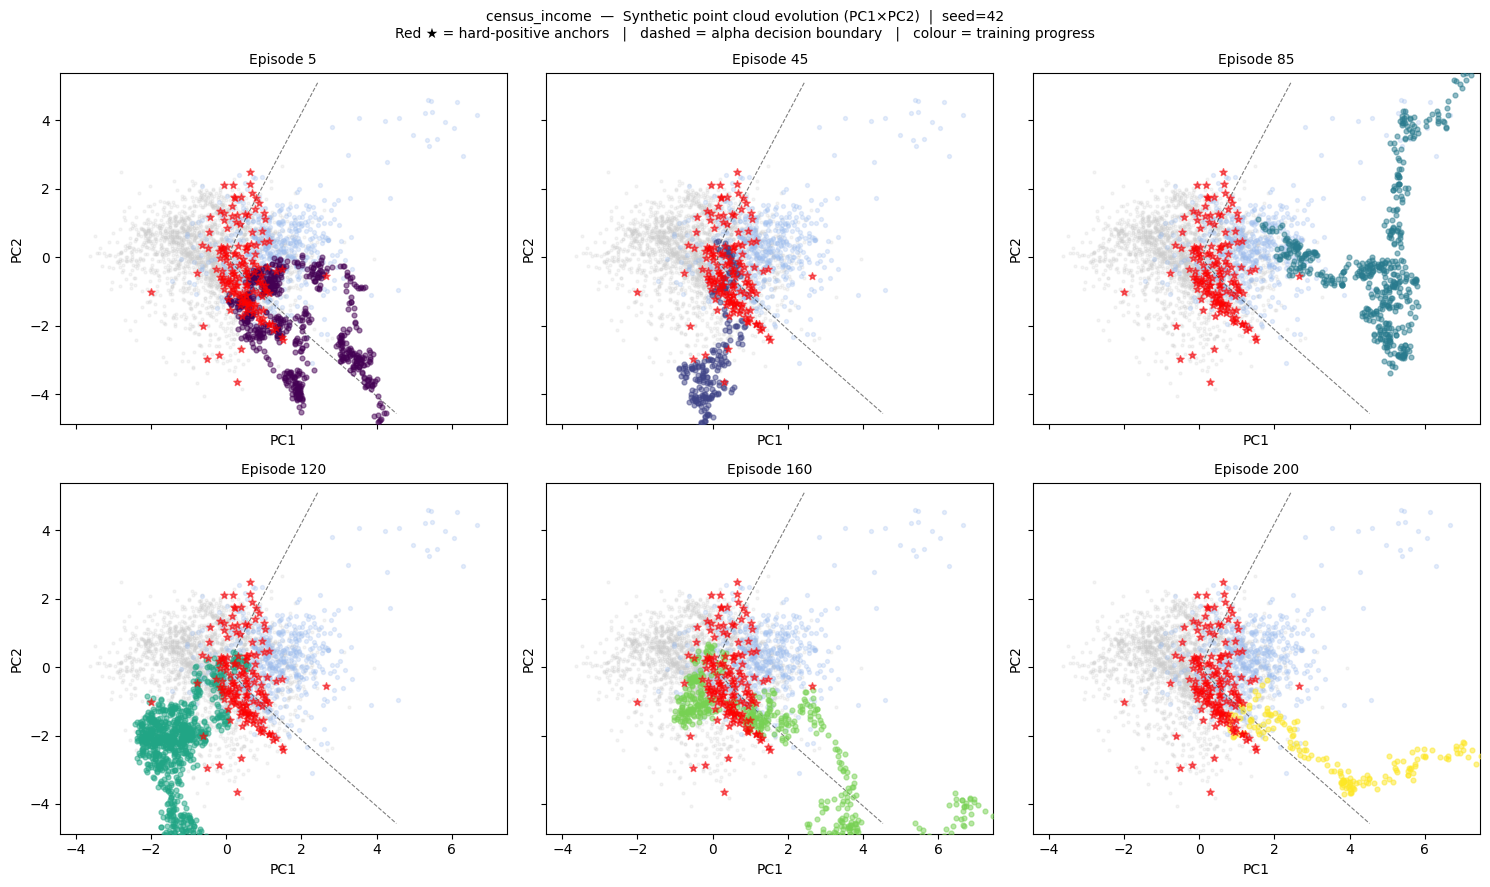

In [5]:
# ============================================================
# CELL 4 – GENERATION DRIFT ACROSS TRAINING SNAPSHOTS
# ============================================================
# Load all saved snapshot files and show how synthetic point cloud evolves.

snap_dir = SEED_DIR / "synthetic_snapshots"
snap_files = sorted(snap_dir.glob("synthetic_ep*_phase1_class1.npz"))

def ep_num(path):
    return int(path.stem.split("_ep")[1].split("_")[0])

all_episodes = np.array([ep_num(f) for f in snap_files])
print(f"Found {len(snap_files)} snapshots: ep {all_episodes.min()} … {all_episodes.max()}")

# ── Choose a subset of episodes to show ──────────────────────
N_PANELS = 6
idx_sel = np.round(np.linspace(0, len(snap_files)-1, N_PANELS)).astype(int)
sel_files = [snap_files[i] for i in idx_sel]
sel_eps   = [ep_num(f) for f in sel_files]

# ── Pre-compute common axis limits ───────────────────────────
MARGIN = 0.8
xlim = (X_tr_np[:, PC_X].min() - MARGIN, X_tr_np[:, PC_X].max() + MARGIN)
ylim = (X_tr_np[:, PC_Y].min() - MARGIN, X_tr_np[:, PC_Y].max() + MARGIN)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
cmap_ep = plt.cm.viridis

for ax, sf, ep in zip(axes.flat, sel_files, sel_eps):
    data = np.load(sf)
    pts  = data["x"]   # shape (N, PCA_COMPONENTS)

    # Background: real data (faint)
    ax.scatter(X_tr_np[maj_mask, PC_X], X_tr_np[maj_mask, PC_Y],
               s=4, c="#cccccc", alpha=0.20, zorder=1)
    ax.scatter(X_tr_np[min_mask, PC_X], X_tr_np[min_mask, PC_Y],
               s=8, c="#99bbee", alpha=0.25, zorder=2)
    # Anchors (fixed reference)
    ax.scatter(anchors_np[:, PC_X], anchors_np[:, PC_Y],
               s=30, c="red", marker="*", alpha=0.55, zorder=4, label="Anchors")
    # Synthetic at this episode
    color_val = (ep - sel_eps[0]) / max(sel_eps[-1] - sel_eps[0], 1)
    ax.scatter(pts[:, PC_X], pts[:, PC_Y],
               s=12, c=cmap_ep(color_val), alpha=0.50, zorder=3)
    # Decision boundary contour
    ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=0.8, linestyles="--", alpha=0.5)

    ax.set_title(f"Episode {ep}", fontsize=10)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel(f"PC{PC_X+1}"); ax.set_ylabel(f"PC{PC_Y+1}")

fig.suptitle(
    f"{DATASET_NAME}  —  Synthetic point cloud evolution (PC{PC_X+1}×PC{PC_Y+1})  |  seed={SEED}\n"
    "Red ★ = hard-positive anchors   |   dashed = alpha decision boundary   |   colour = training progress",
    fontsize=10
)
plt.tight_layout()
plt.show()

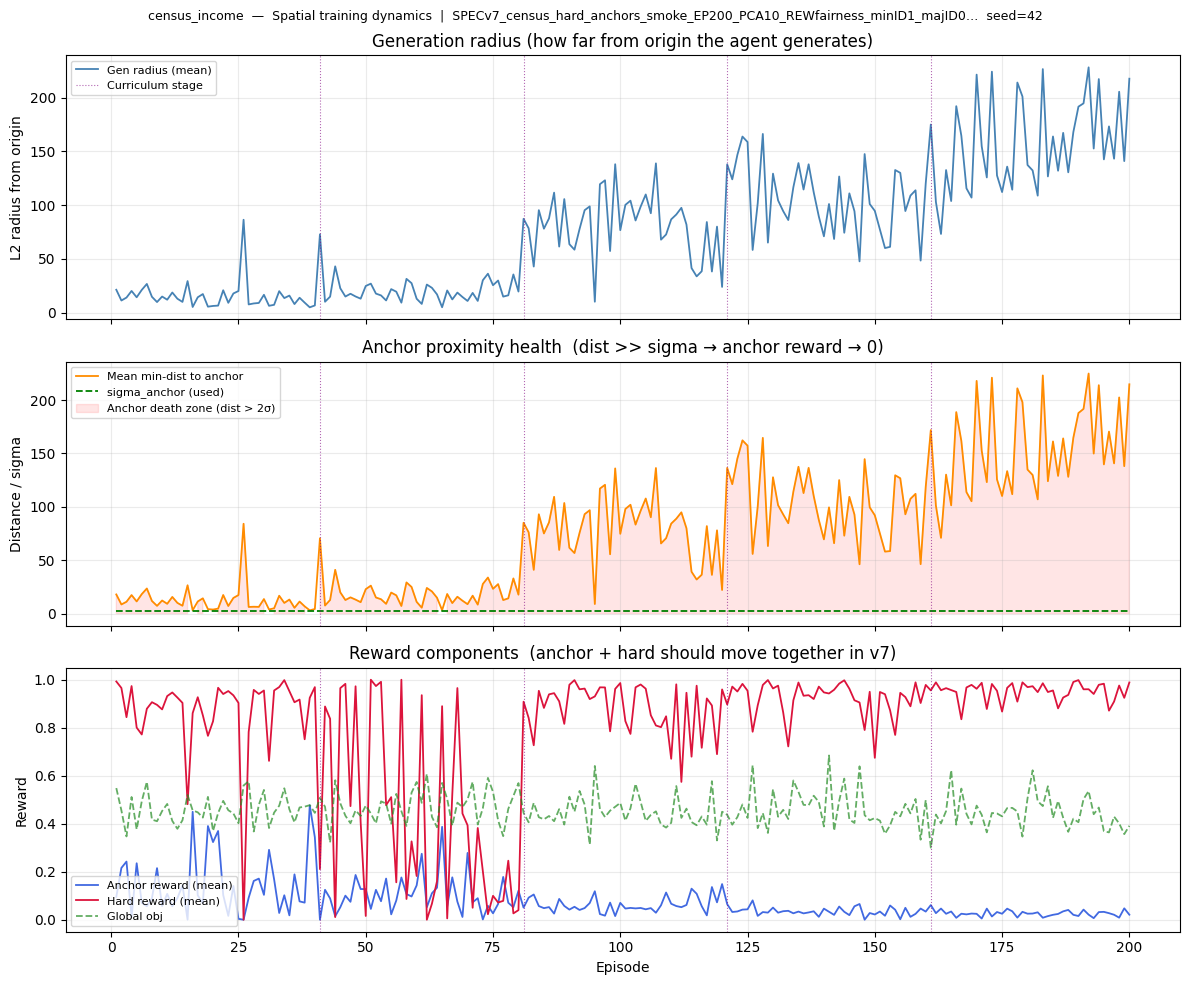

In [6]:
# ============================================================
# CELL 5 – SPATIAL TRAINING DYNAMICS
# ============================================================
# gen_radius, anchor distance vs sigma, anchor/hard rewards
# with curriculum stage transitions marked.

metrics_df = pd.read_csv(SEED_DIR / "metrics.csv")
ep  = metrics_df["episode"].values

# ── Curriculum stage transition episodes ─────────────────────
stage_col = "align.curriculum_stage"
stage_transitions = []
if stage_col in metrics_df.columns:
    stages = metrics_df[stage_col].values
    for i in range(1, len(stages)):
        if stages[i] != stages[i-1]:
            stage_transitions.append(ep[i])

def add_stage_lines(ax, label_first=True):
    for j, e in enumerate(stage_transitions):
        ax.axvline(e, color="purple", lw=0.8, ls=":", alpha=0.6,
                   label="Curriculum stage" if (j == 0 and label_first) else None)

# ── Anchor refresh episodes ───────────────────────────────────
refresh_eps = []
if "align.anchor_refresh_count" in metrics_df.columns:
    rc = metrics_df["align.anchor_refresh_count"].values
    for i in range(1, len(rc)):
        if rc[i] > rc[i-1]:
            refresh_eps.append(ep[i])

def add_refresh_lines(ax, label_first=True):
    for j, e in enumerate(refresh_eps):
        ax.axvline(e, color="teal", lw=0.8, ls="--", alpha=0.5,
                   label="Anchor refresh" if (j == 0 and label_first) else None)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ── Panel 1: Generation radius ────────────────────────────────
ax = axes[0]
if "extra.diag_gen_radius_mean" in metrics_df.columns:
    ax.plot(ep, metrics_df["extra.diag_gen_radius_mean"], c="steelblue", lw=1.3, label="Gen radius (mean)")
radius_clip = meta.get("radius_clip", None)
if radius_clip:
    ax.axhline(radius_clip, color="red", lw=1.2, ls="--", label=f"radius_clip={radius_clip}")
add_stage_lines(ax); add_refresh_lines(ax)
ax.set_ylabel("L2 radius from origin")
ax.set_title("Generation radius (how far from origin the agent generates)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# ── Panel 2: Anchor proximity health ─────────────────────────
ax = axes[1]
has_dist   = "local.min_anchor_dist_mean" in metrics_df.columns
has_sigma  = "local.sigma_anchor_used"    in metrics_df.columns
if has_dist:
    ax.plot(ep, metrics_df["local.min_anchor_dist_mean"], c="darkorange", lw=1.3, label="Mean min-dist to anchor")
if has_sigma:
    ax.plot(ep, metrics_df["local.sigma_anchor_used"],    c="green",      lw=1.3, ls="--", label="sigma_anchor (used)")
    if has_dist:
        # Shade region where dist >> sigma (anchor death zone)
        dist_v  = metrics_df["local.min_anchor_dist_mean"].values
        sigma_v = metrics_df["local.sigma_anchor_used"].values
        dead    = dist_v > 2 * sigma_v
        ax.fill_between(ep, 0, np.maximum(dist_v, sigma_v),
                        where=dead, color="red", alpha=0.10, label="Anchor death zone (dist > 2σ)")
add_stage_lines(ax, label_first=False); add_refresh_lines(ax, label_first=False)
ax.set_ylabel("Distance / sigma")
ax.set_title("Anchor proximity health  (dist >> sigma → anchor reward → 0)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# ── Panel 3: Reward components ────────────────────────────────
ax = axes[2]
if "local.anchor_reward_mean" in metrics_df.columns:
    ax.plot(ep, metrics_df["local.anchor_reward_mean"], c="royalblue",  lw=1.3, label="Anchor reward (mean)")
if "local.hard_reward_mean" in metrics_df.columns:
    ax.plot(ep, metrics_df["local.hard_reward_mean"],   c="crimson",    lw=1.3, label="Hard reward (mean)")
if "global.global_obj" in metrics_df.columns:
    ax.plot(ep, metrics_df["global.global_obj"],        c="forestgreen", lw=1.3, ls="--", alpha=0.7, label="Global obj")
add_stage_lines(ax, label_first=False); add_refresh_lines(ax, label_first=False)
ax.set_xlabel("Episode"); ax.set_ylabel("Reward")
ax.set_title("Reward components  (anchor + hard should move together in v7)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.suptitle(
    f"{DATASET_NAME}  —  Spatial training dynamics  |  {RUN_NAME[:70]}…  seed={SEED}",
    fontsize=9
)
plt.tight_layout()
plt.show()

Computing p_alpha for all snapshots (may take ~10s)…


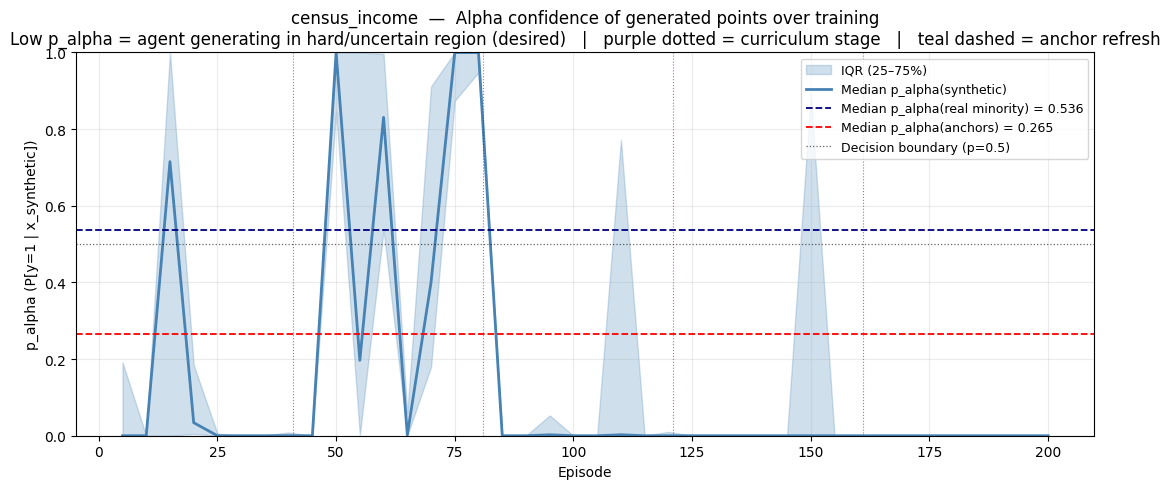

In [7]:
# ============================================================
# CELL 6 – CONFIDENCE PROFILE OF GENERATED POINTS OVER TRAINING
# ============================================================
# For each snapshot, compute p_alpha(x) for every synthetic point.
# Plot the median + IQR over training.
# Goal: low p_alpha = near-boundary / hard region = what we want.

print("Computing p_alpha for all snapshots (may take ~10s)…")

snap_ep_list, p_med_list, p_q25_list, p_q75_list = [], [], [], []

for sf in snap_files:
    ep_n = ep_num(sf)
    data = np.load(sf)
    pts  = data["x"]   # shape (N, PCA_COMPONENTS)
    with torch.no_grad():
        p = rh.p1_from_agent(alpha, torch.tensor(pts.astype(np.float32))).numpy()
    snap_ep_list.append(ep_n)
    p_med_list.append(np.median(p))
    p_q25_list.append(np.percentile(p, 25))
    p_q75_list.append(np.percentile(p, 75))

snap_ep_arr  = np.array(snap_ep_list)
p_med_arr    = np.array(p_med_list)
p_q25_arr    = np.array(p_q25_list)
p_q75_arr    = np.array(p_q75_list)

# Reference lines
with torch.no_grad():
    p_real_minority = rh.p1_from_agent(alpha, torch.tensor(X_tr_np[min_mask].astype(np.float32))).numpy()
    p_anchor_vals   = rh.p1_from_agent(alpha, torch.tensor(anchors_np.astype(np.float32))).numpy()

p_real_min_med = np.median(p_real_minority)
p_anchor_med   = np.median(p_anchor_vals)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(snap_ep_arr, p_q25_arr, p_q75_arr, alpha=0.25, color="steelblue", label="IQR (25–75%)")
ax.plot(snap_ep_arr, p_med_arr, c="steelblue", lw=2.0, label="Median p_alpha(synthetic)")
ax.axhline(p_real_min_med, color="navy",   lw=1.3, ls="--",
           label=f"Median p_alpha(real minority) = {p_real_min_med:.3f}")
ax.axhline(p_anchor_med,   color="red",    lw=1.3, ls="--",
           label=f"Median p_alpha(anchors) = {p_anchor_med:.3f}")
ax.axhline(0.5,            color="black",  lw=0.9, ls=":", alpha=0.6, label="Decision boundary (p=0.5)")

for e in stage_transitions:
    ax.axvline(e, color="purple", lw=0.8, ls=":", alpha=0.6)
for e in refresh_eps:
    ax.axvline(e, color="teal",   lw=0.8, ls="--", alpha=0.5)

ax.set_xlabel("Episode"); ax.set_ylabel("p_alpha (P[y=1 | x_synthetic])")
ax.set_title(
    f"{DATASET_NAME}  —  Alpha confidence of generated points over training\n"
    "Low p_alpha = agent generating in hard/uncertain region (desired)   |   "
    "purple dotted = curriculum stage   |   teal dashed = anchor refresh"
)
ax.set_ylim(0, 1)
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Pearson r(anchor_reward, hard_reward) = -0.0716
  > 0  → anchors and hard reward are pulling in the same direction (good for v7)
  < 0  → anti-correlated (the v3 problem: r was +0.36 with random anchors)

Mean corr_local_delta = -0.1504
  Negative = local reward is anti-correlated with fairness improvement (bad)
  Positive = local reward aligned with global fairness signal (desired)


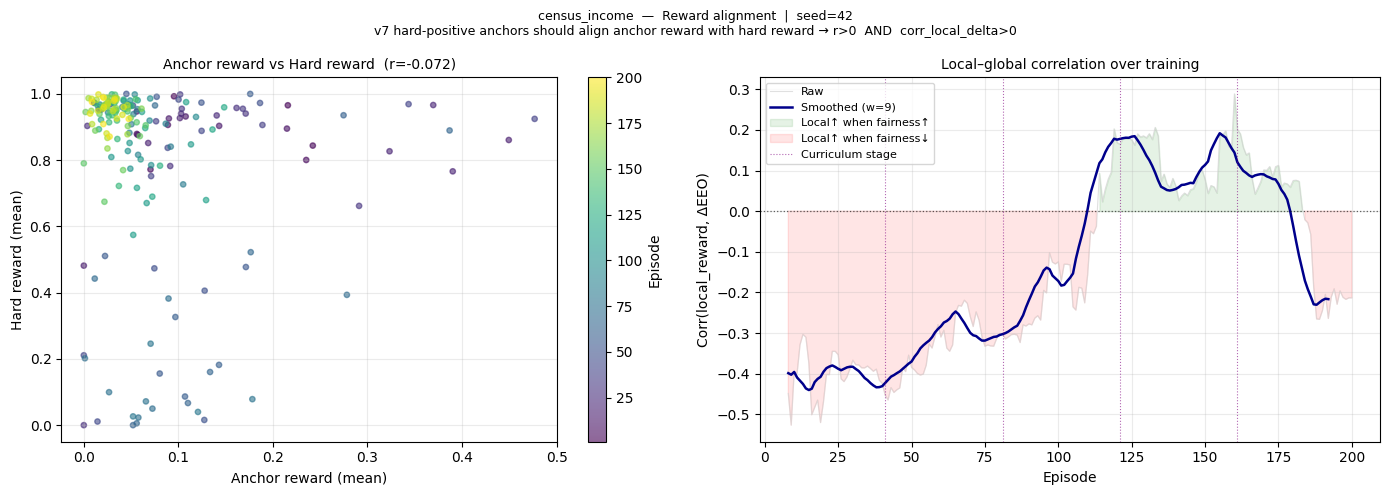

In [8]:
# ============================================================
# CELL 7 – REWARD ALIGNMENT DIAGNOSTIC
# ============================================================
# Scatter: anchor_reward vs hard_reward (coloured by episode).
# Should be correlated in v7 (hard-positive anchors align both).
# Also plot corr_local_delta (local vs global correlation) over time.

has_anchor = "local.anchor_reward_mean" in metrics_df.columns
has_hard   = "local.hard_reward_mean"   in metrics_df.columns
has_corr   = "align.corr_local_delta"   in metrics_df.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Scatter anchor_reward vs hard_reward ─────────────
ax = axes[0]
if has_anchor and has_hard:
    anc_r = metrics_df["local.anchor_reward_mean"].values
    hard_r = metrics_df["local.hard_reward_mean"].values
    sc = ax.scatter(anc_r, hard_r,
                    c=ep, cmap="viridis", s=15, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="Episode")
    # Pearson r
    mask_valid = ~(np.isnan(anc_r) | np.isnan(hard_r))
    r = np.corrcoef(anc_r[mask_valid], hard_r[mask_valid])[0, 1]
    ax.set_title(f"Anchor reward vs Hard reward  (r={r:+.3f})", fontsize=10)
    ax.set_xlabel("Anchor reward (mean)"); ax.set_ylabel("Hard reward (mean)")
    ax.grid(alpha=0.25)
    print(f"Pearson r(anchor_reward, hard_reward) = {r:+.4f}")
    print("  > 0  → anchors and hard reward are pulling in the same direction (good for v7)")
    print("  < 0  → anti-correlated (the v3 problem: r was +0.36 with random anchors)")
else:
    ax.text(0.5, 0.5, "anchor/hard_reward columns not found", ha="center", transform=ax.transAxes)

# ── Panel 2: corr_local_delta over training ───────────────────
ax = axes[1]
if has_corr:
    corr_vals = metrics_df["align.corr_local_delta"].dropna().values
    corr_eps  = metrics_df.loc[metrics_df["align.corr_local_delta"].notna(), "episode"].values
    # Smooth
    window = max(1, len(corr_vals) // 20)
    smooth = np.convolve(corr_vals, np.ones(window)/window, mode="valid")
    sm_ep  = corr_eps[:len(smooth)]
    ax.plot(corr_eps, corr_vals, c="lightgray", lw=0.8, alpha=0.7, label="Raw")
    ax.plot(sm_ep,   smooth,    c="darkblue",  lw=1.8,            label=f"Smoothed (w={window})")
    ax.axhline(0, color="black", lw=0.9, ls=":", alpha=0.6)
    ax.fill_between(corr_eps, corr_vals, 0,
                    where=corr_vals > 0, color="green", alpha=0.10, label="Local↑ when fairness↑")
    ax.fill_between(corr_eps, corr_vals, 0,
                    where=corr_vals < 0, color="red",   alpha=0.10, label="Local↑ when fairness↓")
    add_stage_lines(ax); add_refresh_lines(ax)
    ax.set_xlabel("Episode"); ax.set_ylabel("Corr(local_reward, ΔEEO)")
    ax.set_title("Local–global correlation over training", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    overall_corr = np.nanmean(corr_vals)
    print(f"\nMean corr_local_delta = {overall_corr:+.4f}")
    print("  Negative = local reward is anti-correlated with fairness improvement (bad)")
    print("  Positive = local reward aligned with global fairness signal (desired)")
else:
    ax.text(0.5, 0.5, "align.corr_local_delta column not found", ha="center", transform=ax.transAxes)

fig.suptitle(
    f"{DATASET_NAME}  —  Reward alignment  |  seed={SEED}\n"
    "v7 hard-positive anchors should align anchor reward with hard reward → r>0  AND  corr_local_delta>0",
    fontsize=9
)
plt.tight_layout()
plt.show()

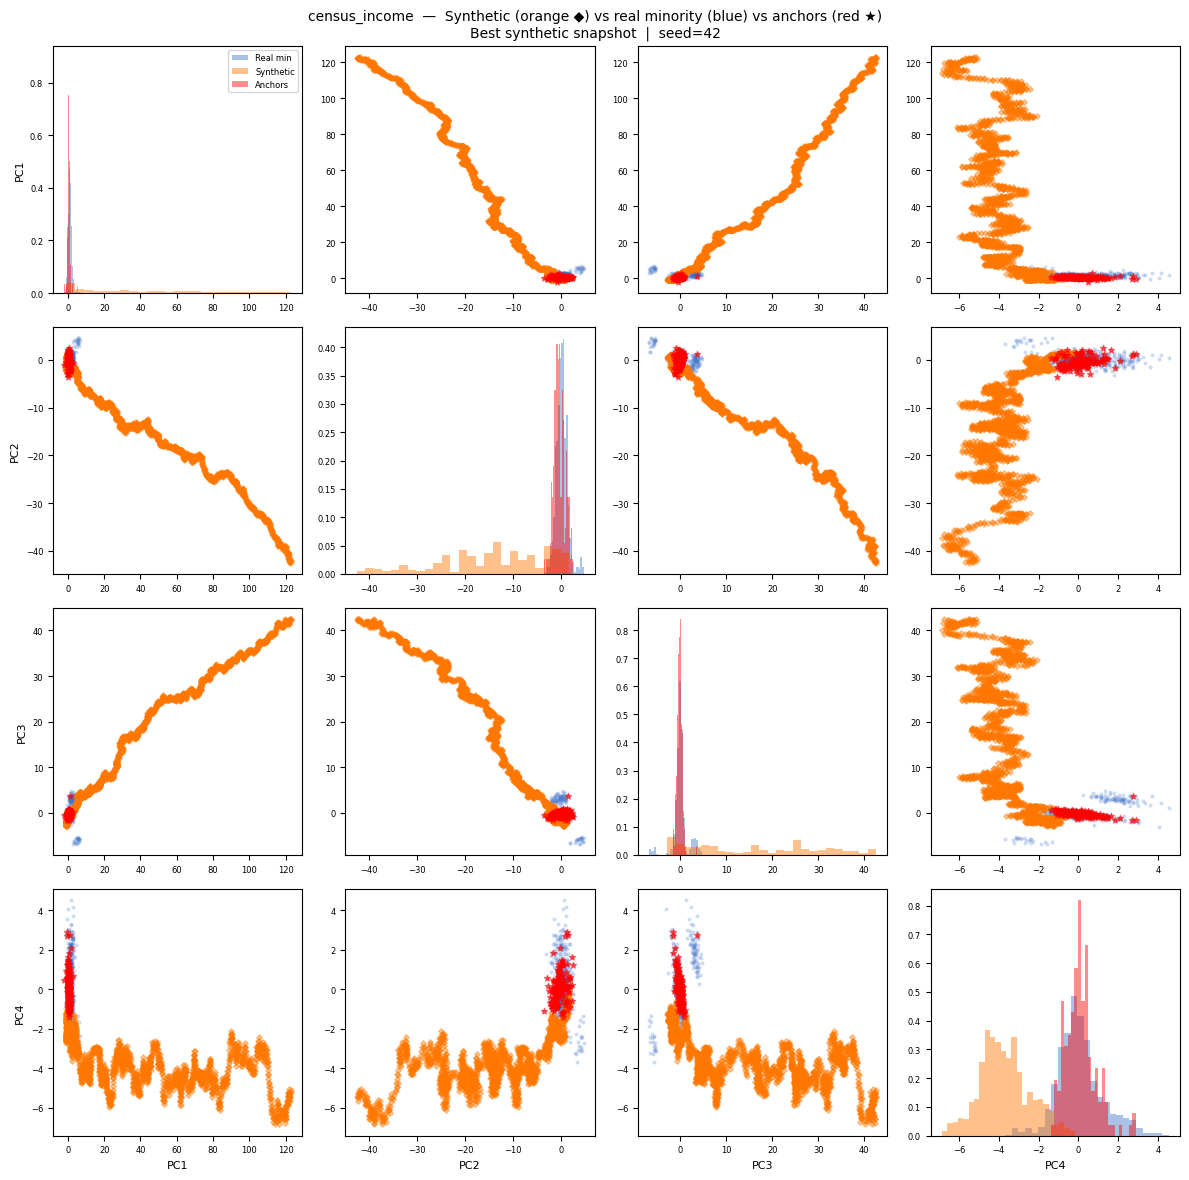

In [9]:
# ============================================================
# CELL 8 – OPTIONAL: BEST SYNTHETIC  PC PAIR GRID
# ============================================================
# Quick pair-plot of the best synthetic points across the top-4 PCA dims.
# Helps check whether coverage looks reasonable beyond PC1×PC2.

N_DIMS = min(4, PCA_COMPONENTS)
fig, axes = plt.subplots(N_DIMS, N_DIMS, figsize=(12, 12))

for i in range(N_DIMS):
    for j in range(N_DIMS):
        ax = axes[i, j]
        if i == j:
            # Diagonal: histogram
            ax.hist(X_tr_np[min_mask, i],  bins=25, color="#4477CC", alpha=0.45, density=True, label="Real min")
            ax.hist(syn_np[:, i],           bins=25, color="#FF7700", alpha=0.45, density=True, label="Synthetic")
            ax.hist(anchors_np[:, i],       bins=25, color="red",     alpha=0.45, density=True, label="Anchors")
            if i == 0: ax.legend(fontsize=6)
        else:
            ax.scatter(X_tr_np[min_mask, j], X_tr_np[min_mask, i], s=4, c="#4477CC", alpha=0.18)
            ax.scatter(syn_np[:, j],         syn_np[:, i],         s=8, c="#FF7700", alpha=0.40, marker="D")
            ax.scatter(anchors_np[:, j],     anchors_np[:, i],     s=20, c="red",   alpha=0.55, marker="*")
        if j == 0: ax.set_ylabel(f"PC{i+1}", fontsize=8)
        if i == N_DIMS-1: ax.set_xlabel(f"PC{j+1}", fontsize=8)
        ax.tick_params(labelsize=6)

fig.suptitle(
    f"{DATASET_NAME}  —  Synthetic (orange ◆) vs real minority (blue) vs anchors (red ★)\n"
    f"Best synthetic snapshot  |  seed={SEED}",
    fontsize=10
)
plt.tight_layout()
plt.show()